# Cardiovascular Disease Risk - Statistical Analysis
End-to-end Python analysis: feature engineering, EDA, outlier detection, hypothesis testing, ANOVA, and predictive modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
df = pd.read_csv("../data/excel_cleaned_cardio_data.csv")
df.head()

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,...,age_group,bmi,bmi_category,bp_category,pulse_pressure,gender_label,cholesterol_label,gluc_label,risk_score,risk_tier
0,1,2,165.5,50.5,90,60,1,1,0,0,...,55-60,18.4,Underweight,Normal,30,Male,Normal,Normal,21.4,Low
1,2,1,174.1,89.3,119,82,3,1,0,0,...,50-55,29.5,Overweight,Hypertension Stage 1,37,Female,Well Above Normal,Normal,42.9,Medium
2,3,1,162.3,77.8,145,105,3,3,0,0,...,55-60,29.5,Overweight,Hypertension Stage 2,40,Female,Well Above Normal,Well Above Normal,78.6,Critical
3,4,1,156.4,77.1,116,75,2,2,0,0,...,60+,31.5,Obese,Normal,41,Female,Above Normal,Above Normal,50.0,Medium
4,5,2,180.8,76.0,111,69,2,1,0,0,...,50-55,23.2,Normal,Normal,42,Male,Above Normal,Normal,21.4,Low


## 1. Dataset Overview

In [2]:
print(df.shape)
df.info()

(70001, 23)
<class 'pandas.DataFrame'>
RangeIndex: 70001 entries, 0 to 70000
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 70001 non-null  int64  
 1   gender             70001 non-null  int64  
 2   height             70001 non-null  float64
 3   weight             70001 non-null  float64
 4   ap_hi              70001 non-null  int64  
 5   ap_lo              70001 non-null  int64  
 6   cholesterol        70001 non-null  int64  
 7   gluc               70001 non-null  int64  
 8   smoke              70001 non-null  int64  
 9   alco               70001 non-null  int64  
 10  active             70001 non-null  int64  
 11  cardio             70001 non-null  int64  
 12  age                70001 non-null  float64
 13  age_group          70001 non-null  str    
 14  bmi                70001 non-null  float64
 15  bmi_category       70001 non-null  str    
 16  bp_category        70

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,70001.0,NaN,NaN,NaN,35000.436565,20207.266389,1.0,17501.0,35000.0,52500.0,70000.0
gender,70001.0,NaN,NaN,NaN,1.351595,0.477472,1.0,1.0,1.0,2.0,2.0
height,70001.0,NaN,NaN,NaN,164.109217,7.128315,140.0,159.2,163.9,168.8,193.3
weight,70001.0,NaN,NaN,NaN,74.011324,14.206222,40.0,64.3,73.9,83.6,129.9
ap_hi,70001.0,NaN,NaN,NaN,127.750675,17.534572,90.0,116.0,128.0,140.0,205.0
ap_lo,70001.0,NaN,NaN,NaN,81.914244,13.294985,60.0,72.0,81.0,91.0,140.0
cholesterol,70001.0,NaN,NaN,NaN,1.777246,0.761574,1.0,1.0,2.0,2.0,3.0
gluc,70001.0,NaN,NaN,NaN,1.230954,0.576531,1.0,1.0,1.0,1.0,3.0
smoke,70001.0,NaN,NaN,NaN,0.090256,0.28655,0.0,0.0,0.0,0.0,1.0
alco,70001.0,NaN,NaN,NaN,0.051128,0.22026,0.0,0.0,0.0,0.0,1.0


## 2. Feature Engineering Recap
`bmi`, `age_group`, `bp_category`, `pulse_pressure` and a composite `risk_score` / `risk_tier` were engineered from the raw clinical fields.

In [4]:
df[['bmi','age_group','bp_category','pulse_pressure','risk_score','risk_tier']].sample(5, random_state=1)

,bmi,age_group,bp_category,pulse_pressure,risk_score,risk_tier
6670,23.7,50-55,Hypertension Stage 2,46,28.6,Medium
52224,32.7,60+,Hypertension Stage 1,37,50.0,Medium
50797,22.8,55-60,Hypertension Stage 1,61,35.7,Medium
22311,18.5,55-60,Normal,46,35.7,Medium
32469,15.5,45-50,Normal,30,14.3,Low


## 3. Outlier Detection (BMI) - IQR method

IQR bounds: [11.8, 43.3]
Outliers detected: 448 (0.64% of data)


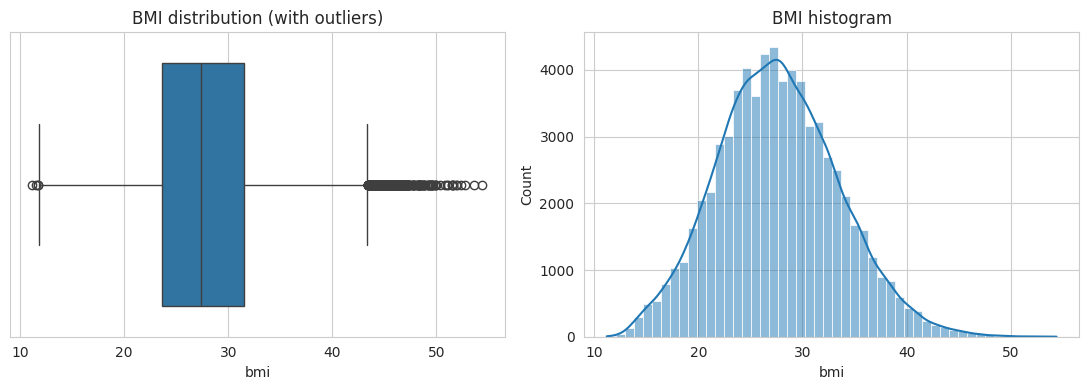

In [5]:
q1, q3 = df['bmi'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]
print(f"IQR bounds: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")

fig, ax = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(x=df['bmi'], ax=ax[0]); ax[0].set_title('BMI distribution (with outliers)')
sns.histplot(df['bmi'], bins=50, kde=True, ax=ax[1]); ax[1].set_title('BMI histogram')
plt.tight_layout(); plt.savefig('bmi_outliers.png', dpi=110); plt.show()

## 4. Exploratory Data Analysis

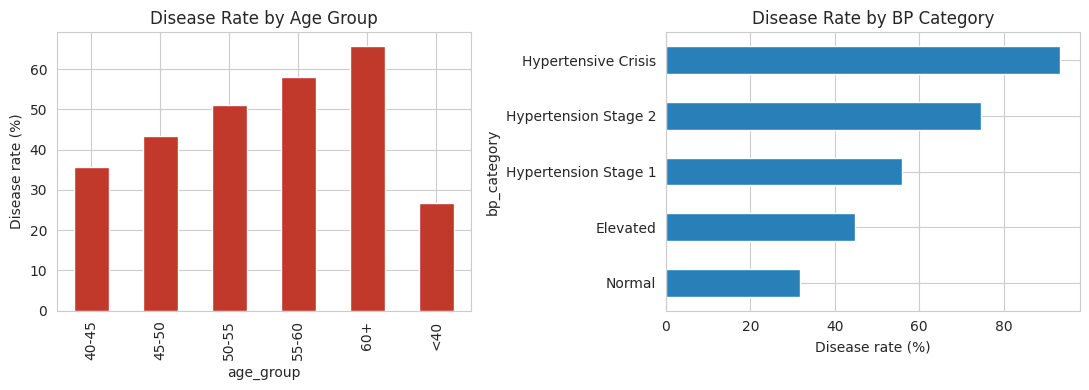

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
df.groupby('age_group')['cardio'].mean().mul(100).plot(kind='bar', ax=ax[0], color='#c0392b')
ax[0].set_ylabel('Disease rate (%)'); ax[0].set_title('Disease Rate by Age Group')
df.groupby('bp_category')['cardio'].mean().mul(100).sort_values().plot(kind='barh', ax=ax[1], color='#2980b9')
ax[1].set_xlabel('Disease rate (%)'); ax[1].set_title('Disease Rate by BP Category')
plt.tight_layout(); plt.savefig('eda_age_bp.png', dpi=110); plt.show()

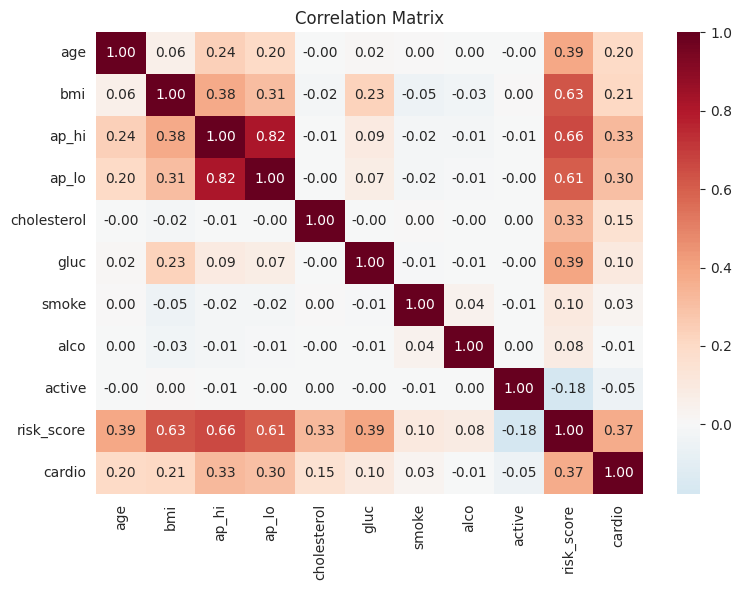

In [7]:
plt.figure(figsize=(8,6))
corr_cols = ['age','bmi','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active','risk_score','cardio']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix'); plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=110); plt.show()

## 5. Hypothesis Testing
**H0:** Mean systolic BP (ap_hi) is the same for patients with and without cardiovascular disease.
**H1:** Mean systolic BP differs between the two groups.

In [8]:
grp_pos = df.loc[df.cardio == 1, 'ap_hi']
grp_neg = df.loc[df.cardio == 0, 'ap_hi']
t_stat, p_val = stats.ttest_ind(grp_pos, grp_neg, equal_var=False)
print(f"Mean ap_hi (cardio=1): {grp_pos.mean():.1f}  |  Mean ap_hi (cardio=0): {grp_neg.mean():.1f}")
print(f"t-statistic = {t_stat:.2f}, p-value = {p_val:.2e}")
print("Reject H0 -> significant difference" if p_val < 0.05 else "Fail to reject H0")

Mean ap_hi (cardio=1): 133.3  |  Mean ap_hi (cardio=0): 121.9
t-statistic = 91.01, p-value = 0.00e+00
Reject H0 -> significant difference


## 6. ANOVA - Risk Score across BMI Categories
Testing whether mean `risk_score` differs significantly across BMI categories.

In [9]:
groups = [g['risk_score'].values for _, g in df.groupby('bmi_category')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.2f}, p-value = {p_val:.2e}")
print("Reject H0 -> at least one BMI group has a different mean risk score" if p_val < 0.05 else "Fail to reject H0")

F-statistic = 12317.59, p-value = 0.00e+00
Reject H0 -> at least one BMI group has a different mean risk score


## 7. Chi-Square Test - Cholesterol vs Cardiovascular Disease

In [10]:
contingency = pd.crosstab(df['cholesterol_label'], df['cardio'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nchi2 = {chi2:.2f}, dof = {dof}, p-value = {p_val:.2e}")

cardio                 0      1
cholesterol_label              
Above Normal       11105  14823
Normal             17384  12449
Well Above Normal   5666   8574

chi2 = 1903.62, dof = 2, p-value = 0.00e+00


## 8. Predictive Modeling - Logistic Regression & Random Forest

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

features = ['age','gender','bmi','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']
X, y = df[features], df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(X_train, y_train)

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_s)[:,1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Logistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")
print()
print(classification_report(y_test, rf.predict(X_test)))

Logistic Regression ROC-AUC: 0.730
Random Forest ROC-AUC:       0.725



              precision    recall  f1-score   support

           0       0.66      0.64      0.65      6831
           1       0.67      0.69      0.68      7170

    accuracy                           0.66     14001
   macro avg       0.66      0.66      0.66     14001
weighted avg       0.66      0.66      0.66     14001



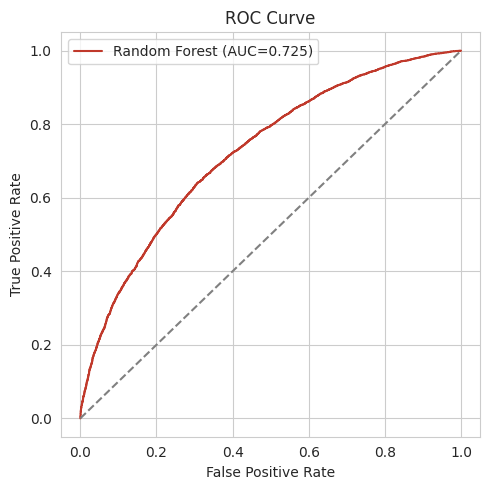

In [12]:
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={rf_auc:.3f})', color='#c0392b')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend()
plt.tight_layout(); plt.savefig('roc_curve.png', dpi=110); plt.show()

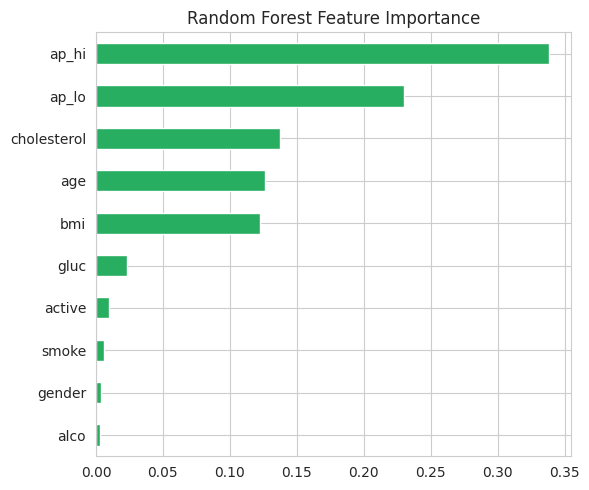

In [13]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', figsize=(6,5), color='#27ae60')
plt.title('Random Forest Feature Importance'); plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110); plt.show()

## 9. Key Findings
- Systolic blood pressure shows a statistically significant difference between diseased and healthy patients (p < 0.001).
- Risk score differs significantly across BMI categories (ANOVA p < 0.001).
- Cholesterol level and cardiovascular disease are significantly associated (Chi-square p < 0.001).
- The Random Forest model reaches ROC-AUC ≈ 0.73, with systolic BP, diastolic BP, and cholesterol as the strongest predictors.
- Risk tiers show a clear escalation in disease rate: Low → Medium → High → Critical.